<a href="https://colab.research.google.com/github/sampabiet90/AIML/blob/LogicMojo-AI-ML-April26-sampa90/Car_Resale_Price_Prediction_using_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\SAMPA\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [4]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\SAMPA\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [6]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\SAMPA\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [10]:
%pip install scikit-learn

You should consider upgrading via the 'c:\Users\SAMPA\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import statsmodels.api as sm
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler

In [13]:
# reading a CSV file named "data.csv" located in the "Data" folder on the your Google Drive and stores it as a DataFrame df
# write your data file path
df = pd.read_csv('C:\\Users\\SAMPA\\Desktop\\Dataset\\CarPred.csv')

In [14]:
df.head()

,make,transmission_type,seats_cop,seats_family,seats_large,fuel_cng,fuel_diesel,fuel_electric,fuel_lpg,fuel_patrol,seller_dealer,seller_self,year,km_driven,engine,max_power,model,selling_price
0,hyundai,0,0,0,1,0,0,1,0,0,0,1,2009,42945,2492,287,verna,210447.937555
1,toyota,0,0,0,1,0,0,0,0,1,1,0,2003,176401,3240,88,corolla,272870.715932
2,ford,1,0,0,0,0,0,0,0,1,1,1,2018,46852,3250,169,aspire,251387.190744
3,honda,1,0,0,0,0,1,0,0,0,1,1,2014,162580,1317,99,jazz,139196.325731
4,hyundai,1,0,0,1,0,1,0,0,0,1,1,2004,11264,3268,196,i10,227022.794299


In [15]:
df.shape

(20000, 18)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               20000 non-null  object 
 1   transmission_type  20000 non-null  int64  
 2   seats_cop          20000 non-null  int64  
 3   seats_family       20000 non-null  int64  
 4   seats_large        20000 non-null  int64  
 5   fuel_cng           20000 non-null  int64  
 6   fuel_diesel        20000 non-null  int64  
 7   fuel_electric      20000 non-null  int64  
 8   fuel_lpg           20000 non-null  int64  
 9   fuel_patrol        20000 non-null  int64  
 10  seller_dealer      20000 non-null  int64  
 11  seller_self        20000 non-null  int64  
 12  year               20000 non-null  int64  
 13  km_driven          20000 non-null  int64  
 14  engine             20000 non-null  int64  
 15  max_power          20000 non-null  int64  
 16  model              200

In [17]:
df.describe()

,transmission_type,seats_cop,seats_family,seats_large,fuel_cng,fuel_diesel,fuel_electric,fuel_lpg,fuel_patrol,seller_dealer,seller_self,year,km_driven,engine,max_power,selling_price
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000
mean,0.499250,0.125150,0.250350,0.500400,0.030850,0.063550,0.123900,0.251050,0.499600,0.49835,0.494100,2010.513900,100041.14725,2999.009900,274.710600,266271.805771
std,0.500012,0.330897,0.433225,0.500012,0.172916,0.243956,0.329476,0.433628,0.500012,0.50001,0.499978,6.355032,57710.68638,1156.559718,129.841543,83920.890732
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,2000.000000,1003.00000,1000.000000,50.000000,-12255.386175
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,2005.000000,50202.75000,1995.000000,162.000000,206372.288854
50%,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,2011.000000,100031.50000,3017.000000,275.000000,266074.359288
75%,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.00000,1.000000,2016.000000,150444.00000,3994.000000,387.000000,326341.517397
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,2021.000000,199990.00000,4999.000000,499.000000,561603.556063


In [20]:
df.isnull().sum()

make                 0
transmission_type    0
seats_cop            0
seats_family         0
seats_large          0
fuel_cng             0
fuel_diesel          0
fuel_electric        0
fuel_lpg             0
fuel_patrol          0
seller_dealer        0
seller_self          0
year                 0
km_driven            0
engine               0
max_power            0
model                0
selling_price        0
dtype: int64

Exploratory Data Analysis-Outliers

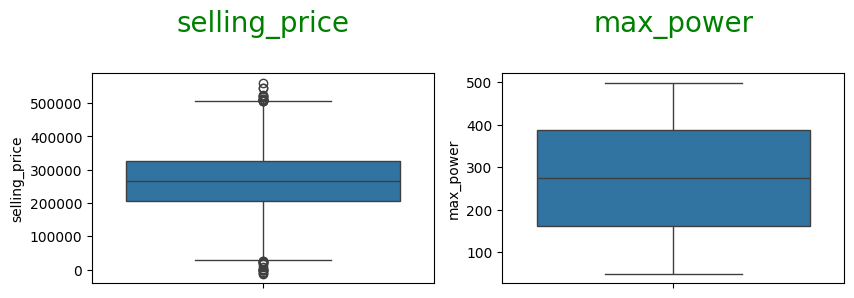

In [18]:
plt.figure(figsize=(15,6))

plt.subplot(2,3,1)
sns.boxplot(df["selling_price"])
plt.title("selling_price\n", fontdict={'fontsize': 20, 'fontweight' : 5, 'color' : 'Green'})

plt.subplot(2,3,2)
sns.boxplot(df["max_power"])
plt.title("max_power\n", fontdict={'fontsize': 20, 'fontweight' : 5, 'color' : 'Green'})



plt.show()

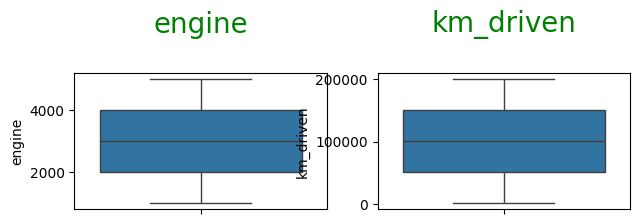

In [10]:
plt.figure(figsize=(15,6))

plt.subplot(3,4,1)
sns.boxplot(df["engine"])
plt.title("engine\n", fontdict={'fontsize': 20, 'fontweight' : 5, 'color' : 'Green'})

plt.subplot(3,4,2)
sns.boxplot(df["km_driven"])
plt.title("km_driven\n", fontdict={'fontsize': 20, 'fontweight' : 5, 'color' : 'Green'})

plt.show()


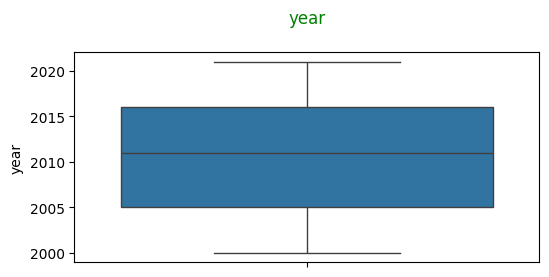

In [11]:
plt.figure(figsize=(6,6))

plt.subplot(2,1,1)
sns.boxplot(df["year"])
plt.title("year\n", fontdict={'fontsize': 12, 'fontweight' : 5, 'color' : 'Green'})




plt.show()

**From the above figure , we can see outliers present  for target variable selling_price. These can be real . so we are keeping those**

In [26]:
current_year = 2026

df["car_age"] = current_year - df["year"]
df.drop(columns=['year'], inplace=True)
df.head()

,make,transmission_type,seats_cop,seats_family,seats_large,fuel_cng,fuel_diesel,fuel_electric,fuel_lpg,fuel_patrol,seller_dealer,seller_self,km_driven,engine,max_power,model,selling_price,max_power_grp,car_age
0,hyundai,0,0,0,1,0,0,1,0,0,0,1,-0.989376,-0.438389,0.094652,verna,210447.937555,201-400,17
1,toyota,0,0,0,1,0,0,0,0,1,1,0,1.323182,0.208373,-1.438024,corolla,272870.715932,50-200,23
2,ford,1,0,0,0,0,0,0,0,1,1,1,-0.921675,0.217020,-0.814171,aspire,251387.190744,50-200,8
3,honda,1,0,0,0,0,1,0,0,0,1,1,1.083689,-1.454358,-1.353303,jazz,139196.325731,50-200,12
4,hyundai,1,0,0,1,0,1,0,0,0,1,1,-1.538352,0.232584,-0.606220,i10,227022.794299,50-200,22


Univariate Analysis

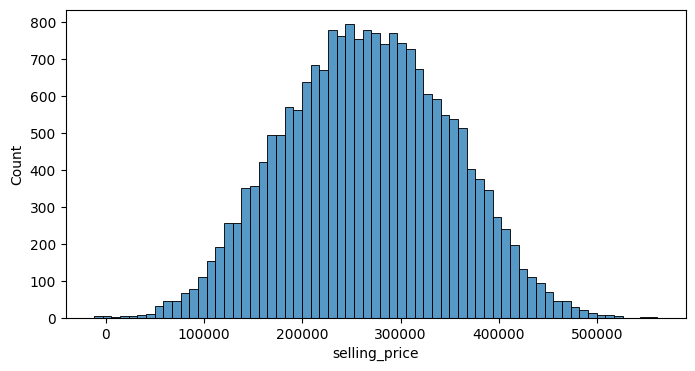

In [27]:
plt.figure(figsize=(8,4))
sns.histplot(df["selling_price"]);

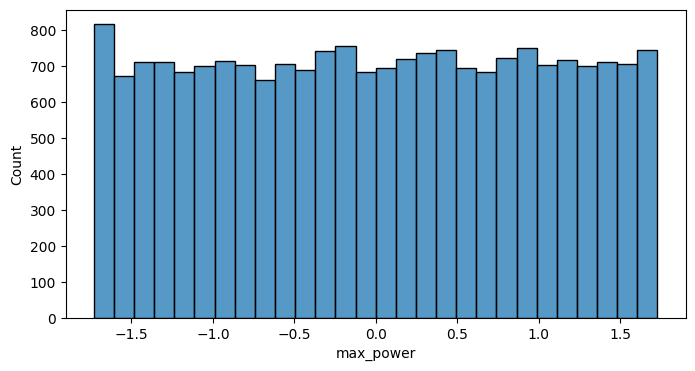

In [28]:
plt.figure(figsize=(8,4))
sns.histplot(df["max_power"]);

<Axes: xlabel='car_age', ylabel='Count'>

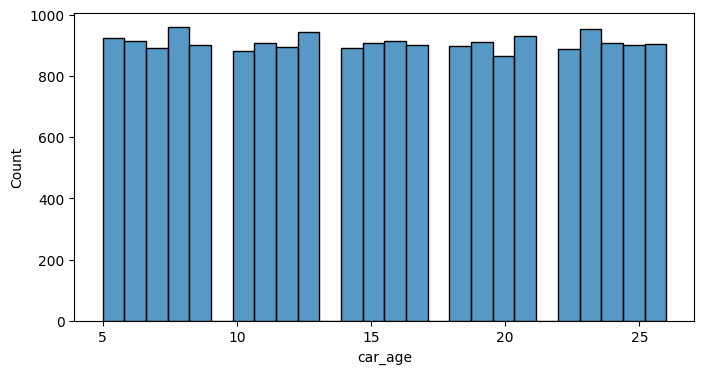

In [29]:
plt.figure(figsize=(8,4))
sns.histplot(df["car_age"])

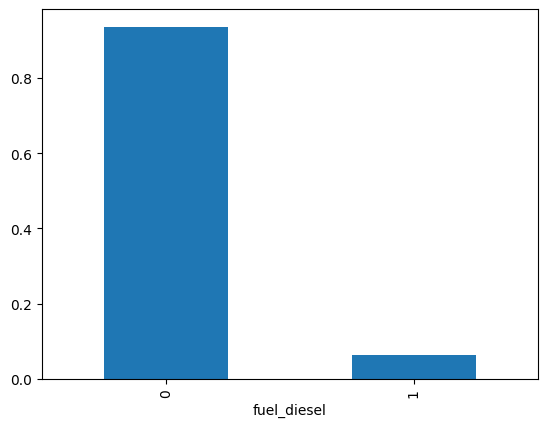

In [30]:

df["fuel_diesel"].value_counts(normalize=True).plot.bar()
plt.show()

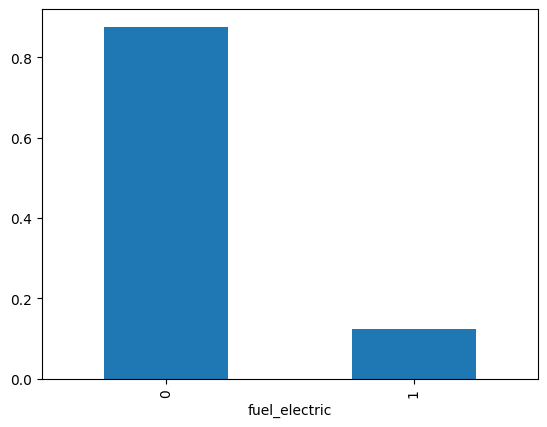

In [31]:
df["fuel_electric"].value_counts(normalize=True).plot.bar()
plt.show()

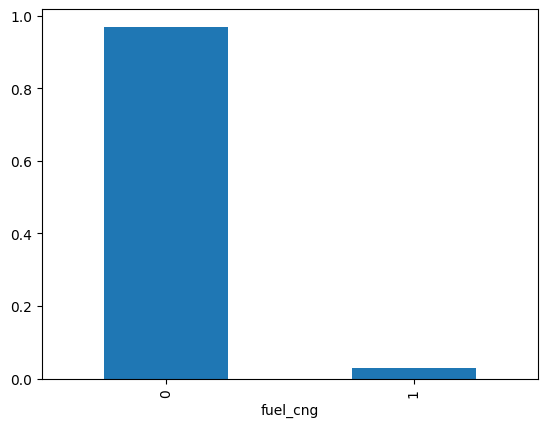

In [32]:
df["fuel_cng"].value_counts(normalize=True).plot.bar()
plt.show()

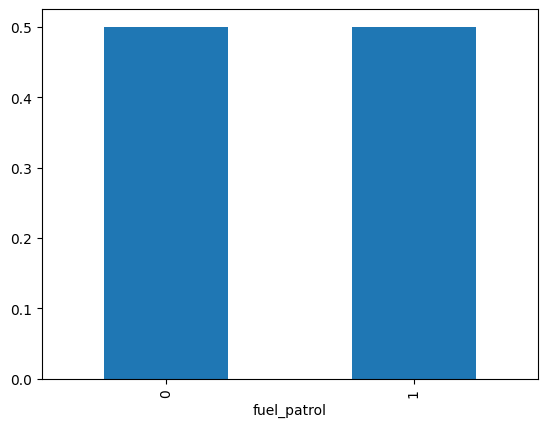

In [33]:
df["fuel_patrol"].value_counts(normalize=True).plot.bar()
plt.show()

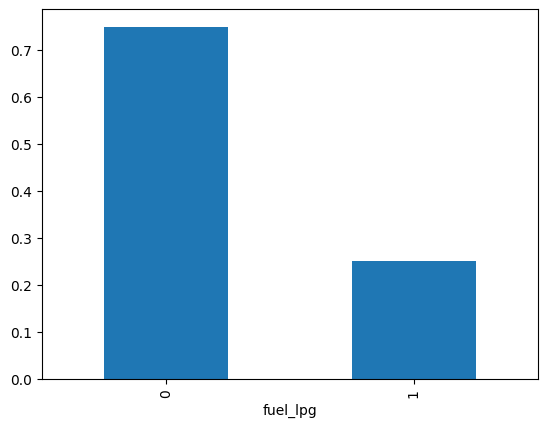

In [34]:
df["fuel_lpg"].value_counts(normalize=True).plot.bar()
plt.show()

<Axes: xlabel='km_driven', ylabel='Count'>

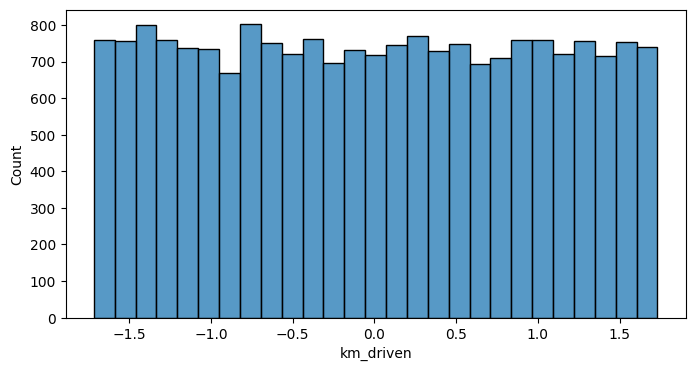

In [35]:

plt.figure(figsize=(8,4))
sns.histplot(df["km_driven"])

<Axes: xlabel='engine', ylabel='Count'>

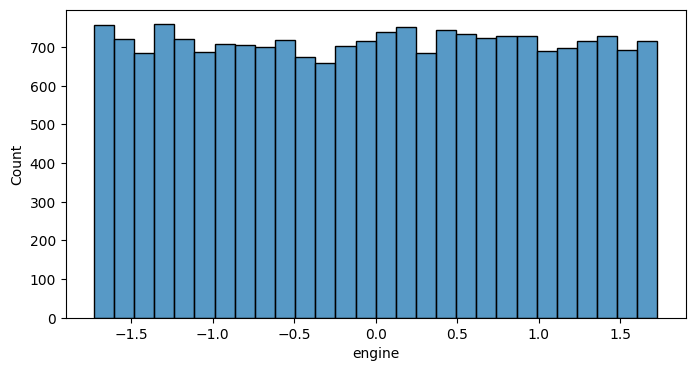

In [36]:
plt.figure(figsize=(8,4))
sns.histplot(df["engine"])

Bivariate Analysis

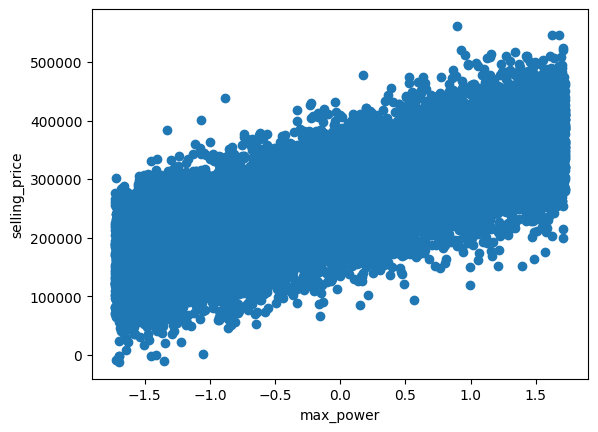

In [37]:
x = df["max_power"].values
y = df["selling_price"].values

plt.scatter(x, y)
plt.xlabel("max_power")
plt.ylabel("selling_price")
plt.show()

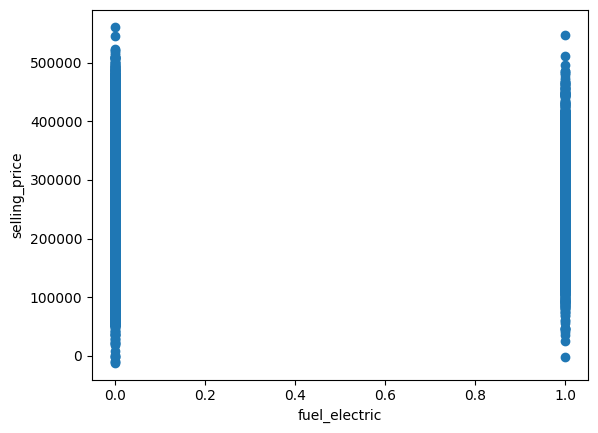

In [38]:
x = df["fuel_electric"].values
y = df["selling_price"].values

plt.scatter(x, y)
plt.xlabel("fuel_electric")
plt.ylabel("selling_price")
plt.show()

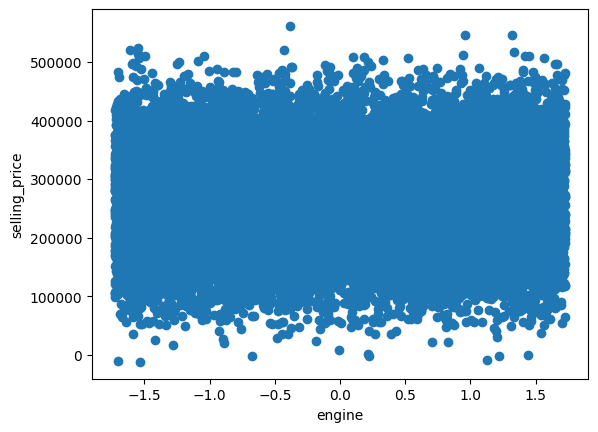

In [39]:
x = df["engine"].values
y = df["selling_price"].values

plt.scatter(x, y)
plt.xlabel("engine")
plt.ylabel("selling_price")
plt.show()

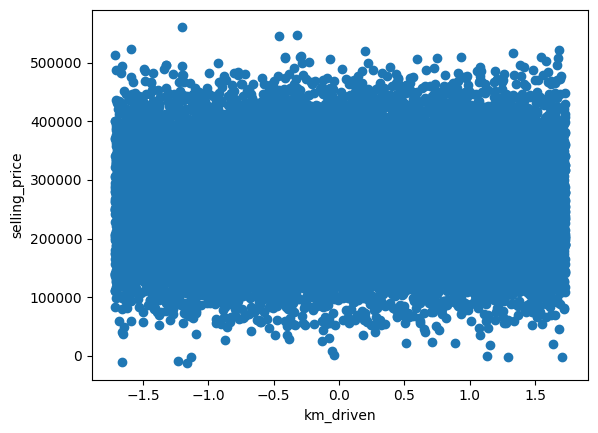

In [40]:
x = df["km_driven"].values
y = df["selling_price"].values

plt.scatter(x, y)
plt.xlabel("km_driven")
plt.ylabel("selling_price")
plt.show()

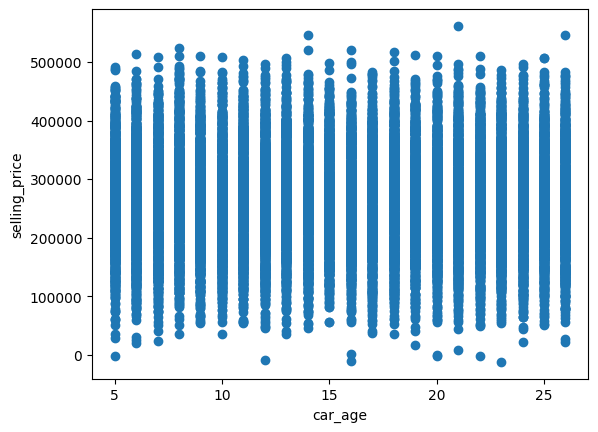

In [41]:
x = df["car_age"].values
y = df["selling_price"].values

plt.scatter(x, y)
plt.xlabel("car_age")
plt.ylabel("selling_price")
plt.show()

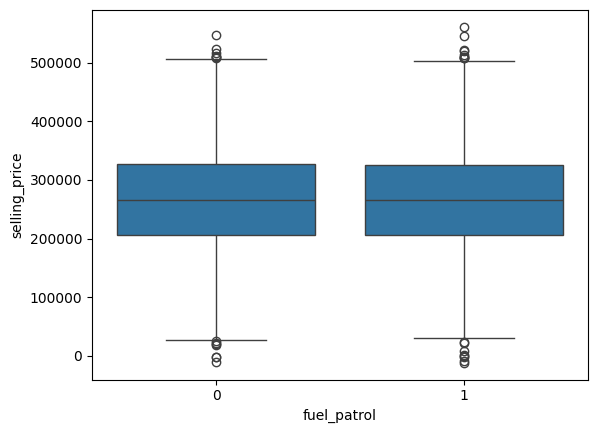

In [42]:
sns.boxplot(x = df["fuel_patrol"], y = df["selling_price"]);

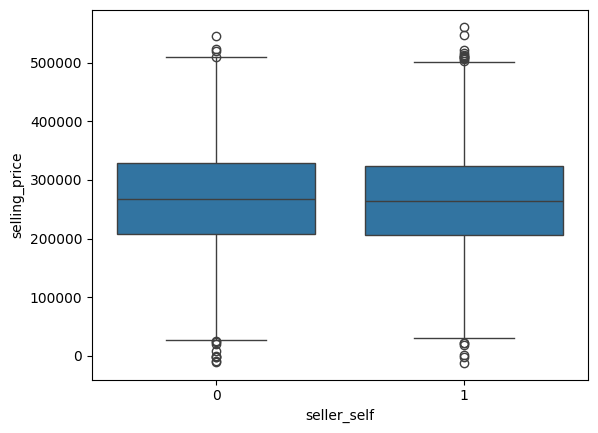

In [43]:
sns.boxplot(x = df["seller_self"], y = df["selling_price"]);

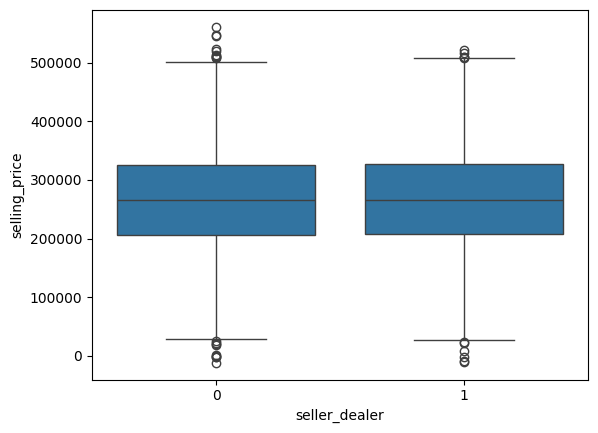

In [44]:
sns.boxplot(x = df["seller_dealer"], y = df["selling_price"]);

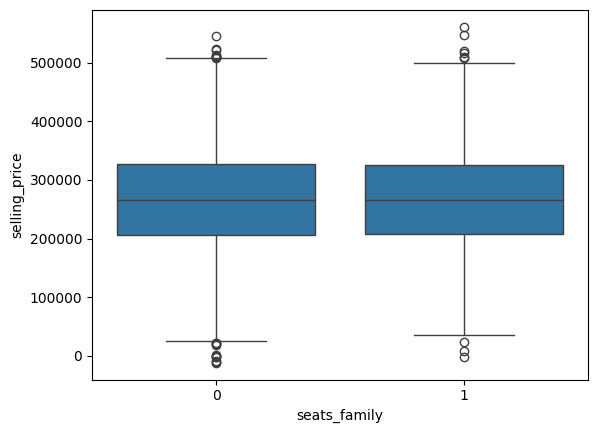

In [45]:
sns.boxplot(x = df["seats_family"], y = df["selling_price"]);

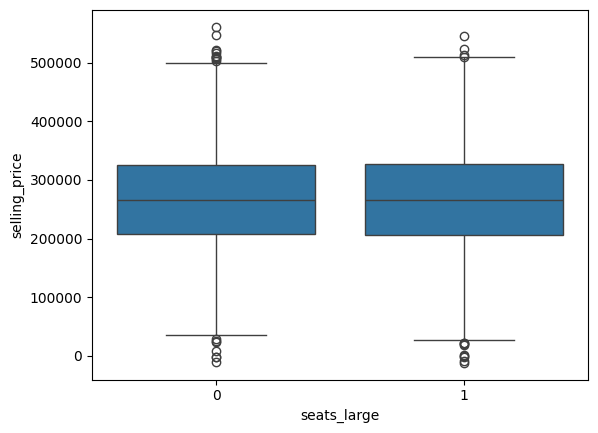

In [46]:
sns.boxplot(x = df["seats_large"], y = df["selling_price"]);

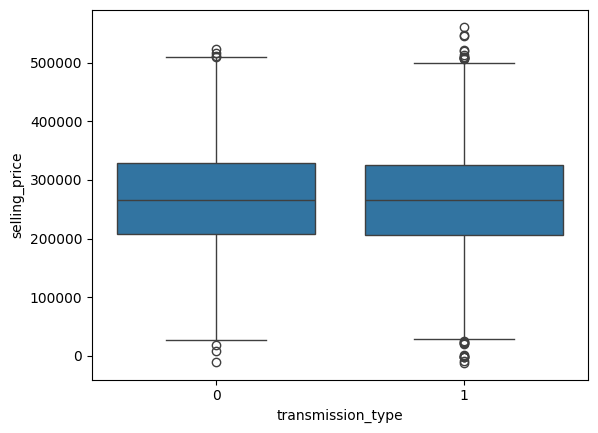

In [47]:

sns.boxplot(x = df["transmission_type"], y = df["selling_price"]);

In [48]:
# max power , engine and km_driven are normally distributed . So we can apply Standard Scalling here

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['km_driven','engine','max_power']] = scaler.fit_transform(df[['km_driven','engine','max_power']])

In [49]:
df

,make,transmission_type,seats_cop,seats_family,seats_large,fuel_cng,fuel_diesel,fuel_electric,fuel_lpg,fuel_patrol,seller_dealer,seller_self,km_driven,engine,max_power,model,selling_price,max_power_grp,car_age
0,hyundai,0,0,0,1,0,0,1,0,0,0,1,-0.989376,-0.438389,0.094652,verna,210447.937555,201-400,17
1,toyota,0,0,0,1,0,0,0,0,1,1,0,1.323182,0.208373,-1.438024,corolla,272870.715932,50-200,23
2,ford,1,0,0,0,0,0,0,0,1,1,1,-0.921675,0.217020,-0.814171,aspire,251387.190744,50-200,8
3,honda,1,0,0,0,0,1,0,0,0,1,1,1.083689,-1.454358,-1.353303,jazz,139196.325731,50-200,12
4,hyundai,1,0,0,1,0,1,0,0,0,1,1,-1.538352,0.232584,-0.606220,i10,227022.794299,50-200,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,toyota,0,0,1,0,0,0,0,0,1,1,0,-1.280161,1.008179,1.704346,corolla,390288.866421,>400,9
19996,hyundai,1,0,0,1,1,0,0,0,0,1,0,0.364272,0.142659,-0.868084,i10,278819.752112,50-200,15
19997,honda,1,1,0,0,0,0,0,0,0,0,0,0.962218,-0.402938,0.187074,civic,207397.304669,201-400,21
19998,honda,1,0,0,1,0,0,0,0,1,0,0,1.614072,-0.850829,-1.153054,city,183440.751987,50-200,18


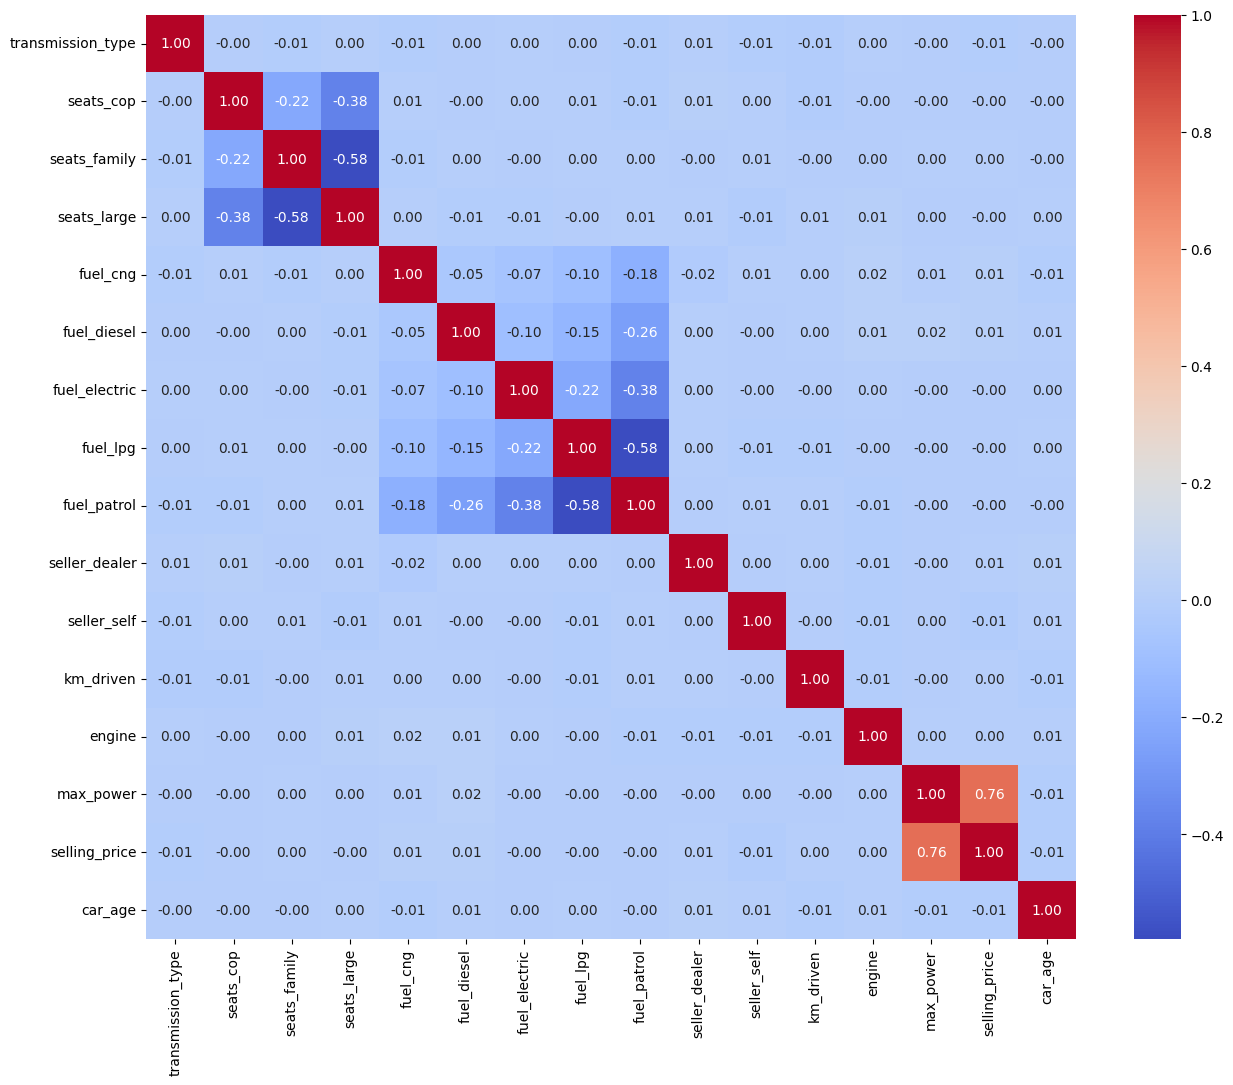

In [53]:
# Analyse co-lineraity
plt.figure(figsize=(15, 12))
sns.heatmap(df.corr(numeric_only=True),cmap='coolwarm',annot=True,fmt=".2f")
plt.show()

**Multivariate Analysis**

From the above analysis, we can conclude:-

*   max_power > 400 tend to have higher selling price
*   As max power increases , selling price increases



**Linear Regression**

In [61]:
# Fit linear regression model
X = df[[ 'km_driven', 'engine', 'max_power', 'car_age']]
y = df['selling_price']

#Split data into test and train

X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=42)

In [62]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, median_absolute_error
model = LinearRegression()
model.fit(X_train, y_train)
yhat = model.predict(X_test)
r2_score(y_test, yhat)

0.5687445036658748

**No Perfect Multicollinearity**

In [63]:
# Check for multicollinearity using variance inflation factor (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i)
              for i in range(X.shape[1])]

print(vif)

     Feature       VIF
0  km_driven  1.000100
1     engine  1.000105
2  max_power  1.000020
3    car_age  1.000017


**Our intention should be lowering the value good R2 metric and VIF is less than 5**

**Linear Regression Model Development Steps:**

Develop a univariate linear regression model


to predict the selling price based on the input variable, max power.


Define three functions: linear hypothesis, gradient computation, and error computation.


Implement gradient descent to optimize the model parameters (Theta 0 and Theta 1).


Stopped gradient descent after a fixed number of iterations (e.g., 50).


Explain the importance of early stopping conditions for efficiency.